*# 🧠 Fake News Detection Using Machine Learning

Project Overview:

In today’s digital world, most people get their news from online platforms and social media.
While this makes information easily accessible, it also leads to the rapid spread of fake news.
It is very difficult for people to manually verify whether every news article is true or false.

In this project, I have tried to solve this problem by building a machine learning model
that can automatically classify news articles as "Fake" or "Real" based on their content.

Objective:

The main goal of this project is to create a system that can analyze the text of a news article
and predict whether it is fake or real. This helps in reducing misinformation and improving
the reliability of online content.

Approach:

To achieve this, I followed these steps:

- First, I loaded and combined datasets containing fake and real news articles
- Then, I cleaned and preprocessed the text data
- I performed exploratory data analysis (EDA) to understand the dataset
- Converted text into numerical form using TF-IDF
- Applied different machine learning models such as:
  Logistic Regression, Decision Tree, Random Forest, and ANN
- Finally, I evaluated and compared the performance of all models

Expected Outcome:

By the end of this project, the model should be able to predict whether a given news article
is fake or real with good accuracy.

*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
fake = pd.read_csv('/content/Fake.csv')
true = pd.read_csv('/content/True.csv')

In [ ]:
fake['label'] = 0
true['label'] = 1

In [ ]:
data = pd.concat([fake, true])
data = data.sample(frac=1).reset_index(drop=True)

In [ ]:
data.head()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


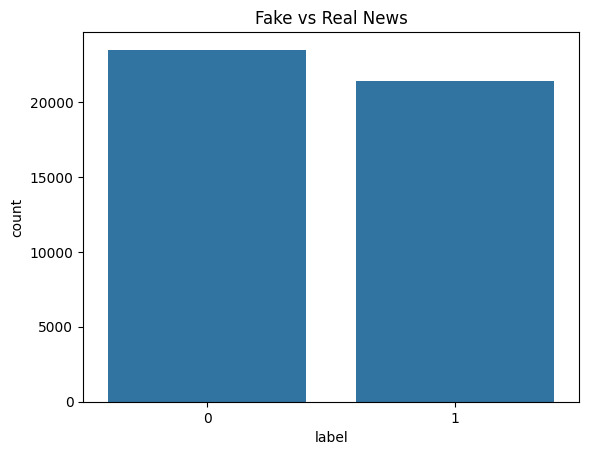

In [ ]:
sns.countplot(x='label', data=data)
plt.title("Fake vs Real News")
plt.show()

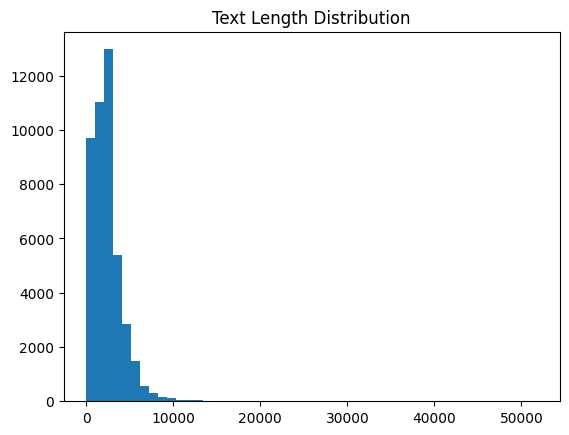

In [ ]:
data['text_length'] = data['text'].apply(len)

plt.hist(data['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

In [ ]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

data['text'] = data['text'].apply(clean_text)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(data['text']).toarray()
y = data['label']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9867483296213808
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4682
           1       0.98      0.99      0.99      4298

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9943207126948775
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4682
           1       1.00      0.99      0.99      4298

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9969933184855234
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4682
           1       1.00      1.00      1.00      4298

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [ ]:
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)
ann.fit(X_train, y_train)

y_pred_ann = ann.predict(X_test)

print("ANN Accuracy:", accuracy_score(y_test, y_pred_ann))
print(classification_report(y_test, y_pred_ann))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


ANN Accuracy: 0.9902004454342984
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4682
           1       0.99      0.99      0.99      4298

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



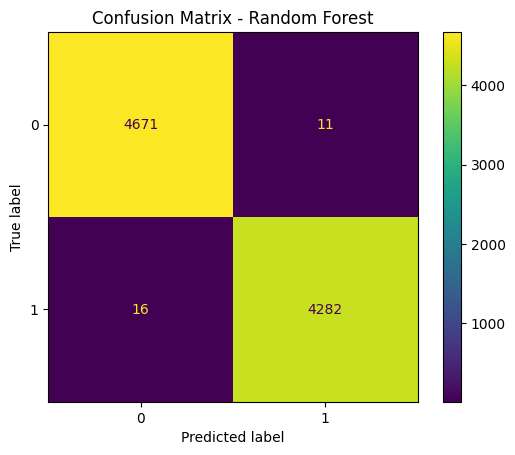

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Confusion Matrix - Random Forest")
plt.show()

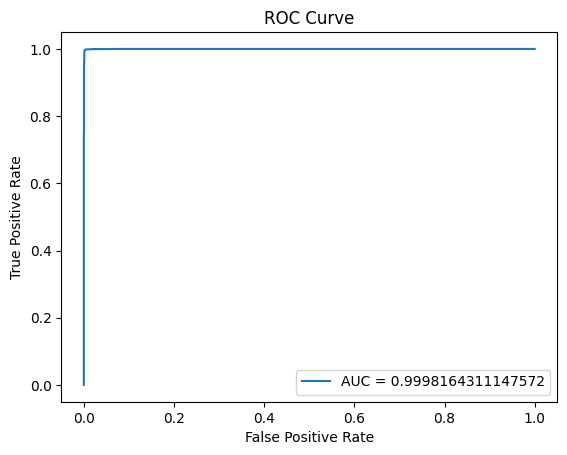

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'ANN']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_ann)
]

comparison = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.986748
1        Decision Tree  0.994321
2        Random Forest  0.996993
3                  ANN  0.990200


In [ ]:
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("ANN:", accuracy_score(y_test, y_pred_ann))

Logistic Regression: 0.9867483296213808
Decision Tree: 0.9943207126948775
Random Forest: 0.9969933184855234
ANN: 0.9902004454342984


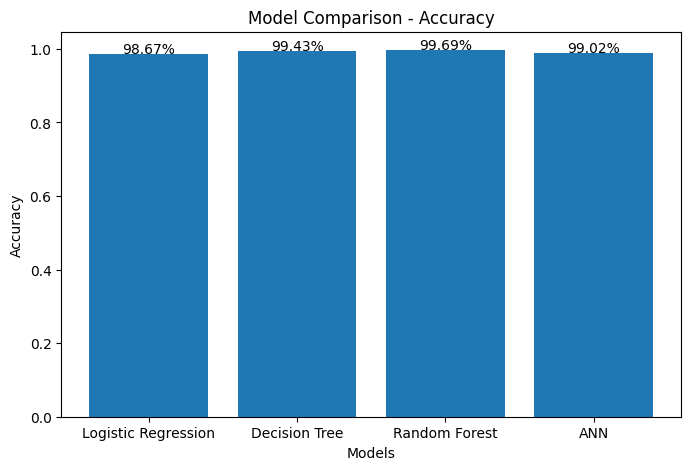

In [ ]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'ANN']
accuracies = [0.9867, 0.9943, 0.9969, 0.9902]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Model Comparison - Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.0005, str(round(v*100,2)) + "%", ha='center')

plt.show()

# ✅ Conclusion

In this project, I successfully built a machine learning model to detect fake news
using textual data.

I started by cleaning and preparing the dataset, and then converted the text into
a numerical format using TF-IDF. After that, I applied multiple machine learning
algorithms including Logistic Regression, Decision Tree, Random Forest, and ANN.

After comparing all the models using performance metrics like accuracy, precision,
recall, and F1-score, I found that the Random Forest model performed the best.
This is because it combines multiple decision trees and gives more accurate results.

What I learned from this project:

- How to work with real-world text data
- The importance of data preprocessing
- How different machine learning models perform on the same problem
- How to evaluate and compare models properly

This project clearly shows how machine learning can be used to solve real-world
problems like fake news detection and help in reducing the spread of misinformation.

Future Improvements:

In the future, this project can be improved by using advanced models like deep learning
(LSTM or BERT), and by using real-time data from social media platforms.

Overall, this project helped me understand both the technical and practical aspects
of machine learning.
